In [1]:
#ECG SIGNAL PROCESSING
#Project 4 - Aagya DSP Portfolio

!pip install wfdb -q

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from wfdb import rdrecord, rdann
%matplotlib inline

print("All libraries ready!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 37.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
All libraries ready!


In [2]:
#download real ecg from physionet
import wfdb
#download MIT-BTH Arrhythmia  Database
#record 100- one of the most studied ecg recordings
record = wfdb.rdrecord('mitdb/100',
                       sampfrom = 0,
                       sampto = 10000,
                       pn_dir = 'mitdb')
#get the ecg signal
ecg_raw = record.p_signal[:,0] #channel 0
fs = record.fs #samping frequency

print(f"ECG loaded succesfully!")
print(f"Sample rate:{fs}Hz")
print(f"Total samples:{len(ecg_raw)}")
print(f"Duration: {len(ecg_raw)/fs:.2f} seconds")
print(f"Max amplitude: {np.max(ecg_raw):.4f} mV")
print(f"Min amplitude:{np.min(ecg_raw):.4f} mV")

ECG loaded succesfully!
Sample rate:360Hz
Total samples:10000
Duration: 27.78 seconds
Max amplitude: 1.0500 mV
Min amplitude:-0.6800 mV


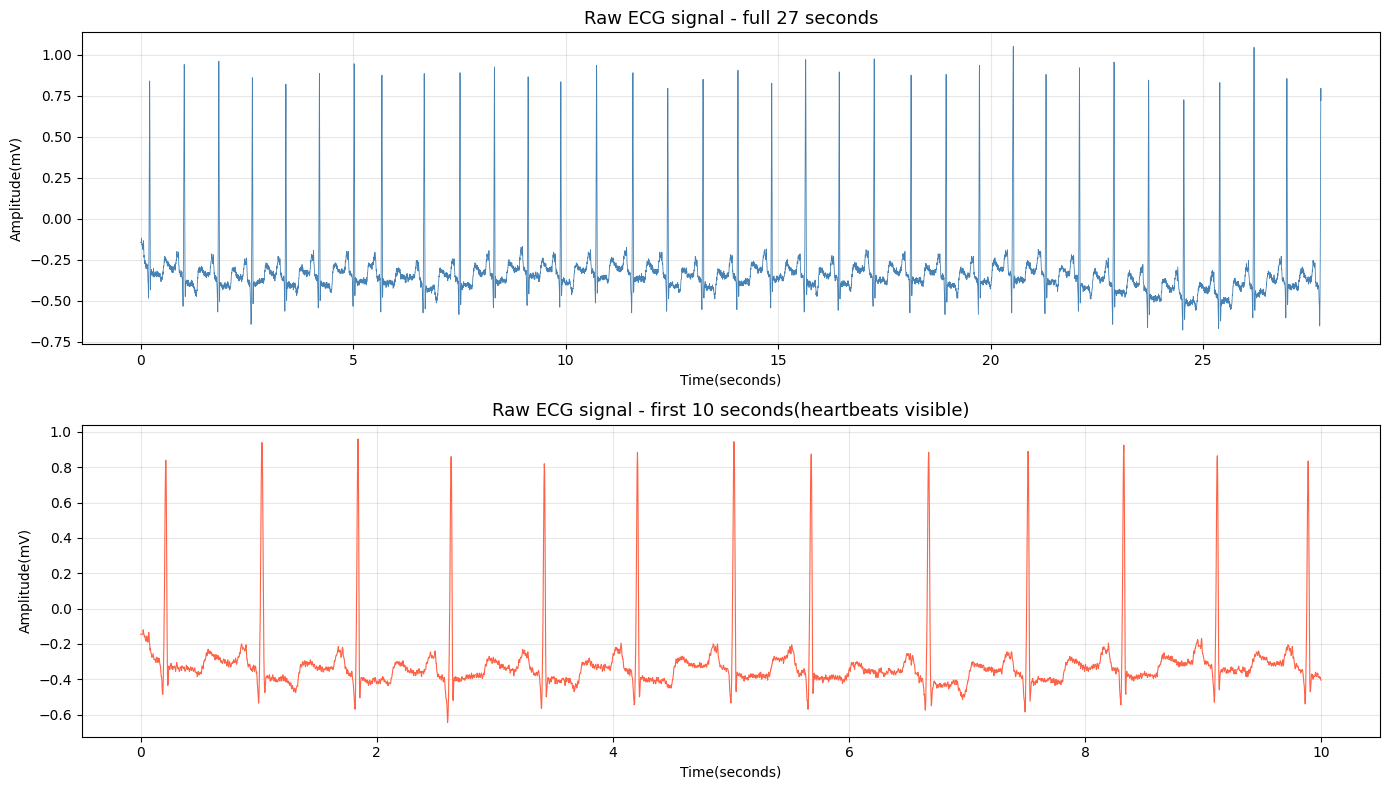

Saved  ecg_raw.png


In [3]:
#cell 3:plot raw ecg signal
#create time axis
t = np.arange(len(ecg_raw))/fs

#plot first 10 seconds only - easier to see heartbeats
samples_10s = 10*fs #10 seconds x 360 Hz = 3600 samples

fig,axes = plt.subplots(2,1,figsize = (14,8))

#full signal
axes[0].plot(t ,ecg_raw, color ='steelblue',linewidth=0.6)
axes[0].set_title('Raw ECG signal - full 27 seconds', fontsize = 13)
axes[0].set_xlabel('Time(seconds)')
axes[0].set_ylabel('Amplitude(mV)')
axes[0].grid(True, alpha=0.3)

#Zoomed - first 10 seconds
axes[1].plot(t[:samples_10s],ecg_raw[:samples_10s], color='tomato',linewidth=0.8)
axes[1].set_title('Raw ECG signal - first 10 seconds(heartbeats visible)', fontsize = 13)
axes[1].set_xlabel('Time(seconds)')
axes[1].set_ylabel('Amplitude(mV)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ecg_raw.png',dpi=150)
plt.show()

print("Saved  ecg_raw.png")

R-peaks found in 5 seconds:6
Estimated heart rate : 72 BPM


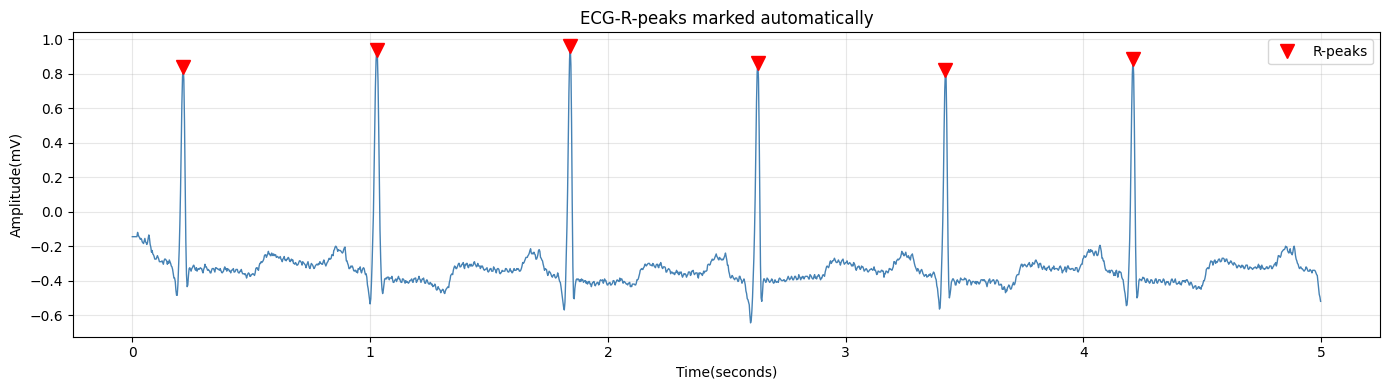

In [4]:
#cell 4 : Find and mark R-peaks automatically
from scipy.signal import find_peaks
samples_5s = 5*fs

#find peaks-height>0.3mV, minimum distance 150 samples apart
peaks,_ = find_peaks(ecg_raw[:samples_5s],
                     height = 0.3,
                     distance = 150)
print(f"R-peaks found in 5 seconds:{len(peaks)}")
print(f"Estimated heart rate : {len(peaks)*12} BPM")

#plot with peaks marked
fig,ax = plt.subplots(figsize =(14,4))
ax.plot(t[:samples_5s],ecg_raw[:samples_5s],
        color = 'steelblue', linewidth = 1.0)
ax.plot(t[peaks],ecg_raw[peaks],
        'rv',markersize = 10, label = 'R-peaks')
ax.set_title('ECG-R-peaks marked automatically')
ax.set_xlabel('Time(seconds)')
ax.set_ylabel('Amplitude(mV)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




In [5]:
#cell 5: apply FIR bandpass filter to clean ECG
#design bandpass fir filter
#pass only 0.5Hz to 40  Hz - the useful ECG frequency range
low_cut = 0.5 #removes baseline wander below 0.5Hz
high_cut = 40.0 #removes muscle noise above 40Hz
numtaps = 101 # filter length -same as Voiceforge!

#Design filter using firwin - same function as Voiceforge!
b = signal.firwin(
    numtaps,
    [low_cut,high_cut],
    pass_zero  = False,
    fs=fs
)

#apply zero-phase filter - same as Voiceforge
ecg_clean = signal.filtfilt(b,1,ecg_raw)

#compaare rms before and after
rms_before = np.sqrt(np.mean(ecg_raw**2))
rms_after = np.sqrt(np.mean(ecg_clean**2))
noise_removed = ((rms_before-rms_after)/rms_before)*100

print(f"FIR bandpass filter applied!")
print(f"Cutoff frequencies : {low_cut}Hz - {high_cut}Hz")
print(f"Filter taps :{numtaps}")
print(f"RMS before filtering: {rms_before:.4f}mV")
print(f"RMS after filtering: {rms_after:.4f}mV")
print(f"Noise removed: {noise_removed:.1f}%")

FIR bandpass filter applied!
Cutoff frequencies : 0.5Hz - 40.0Hz
Filter taps :101
RMS before filtering: 0.3746mV
RMS after filtering: 0.2918mV
Noise removed: 22.1%


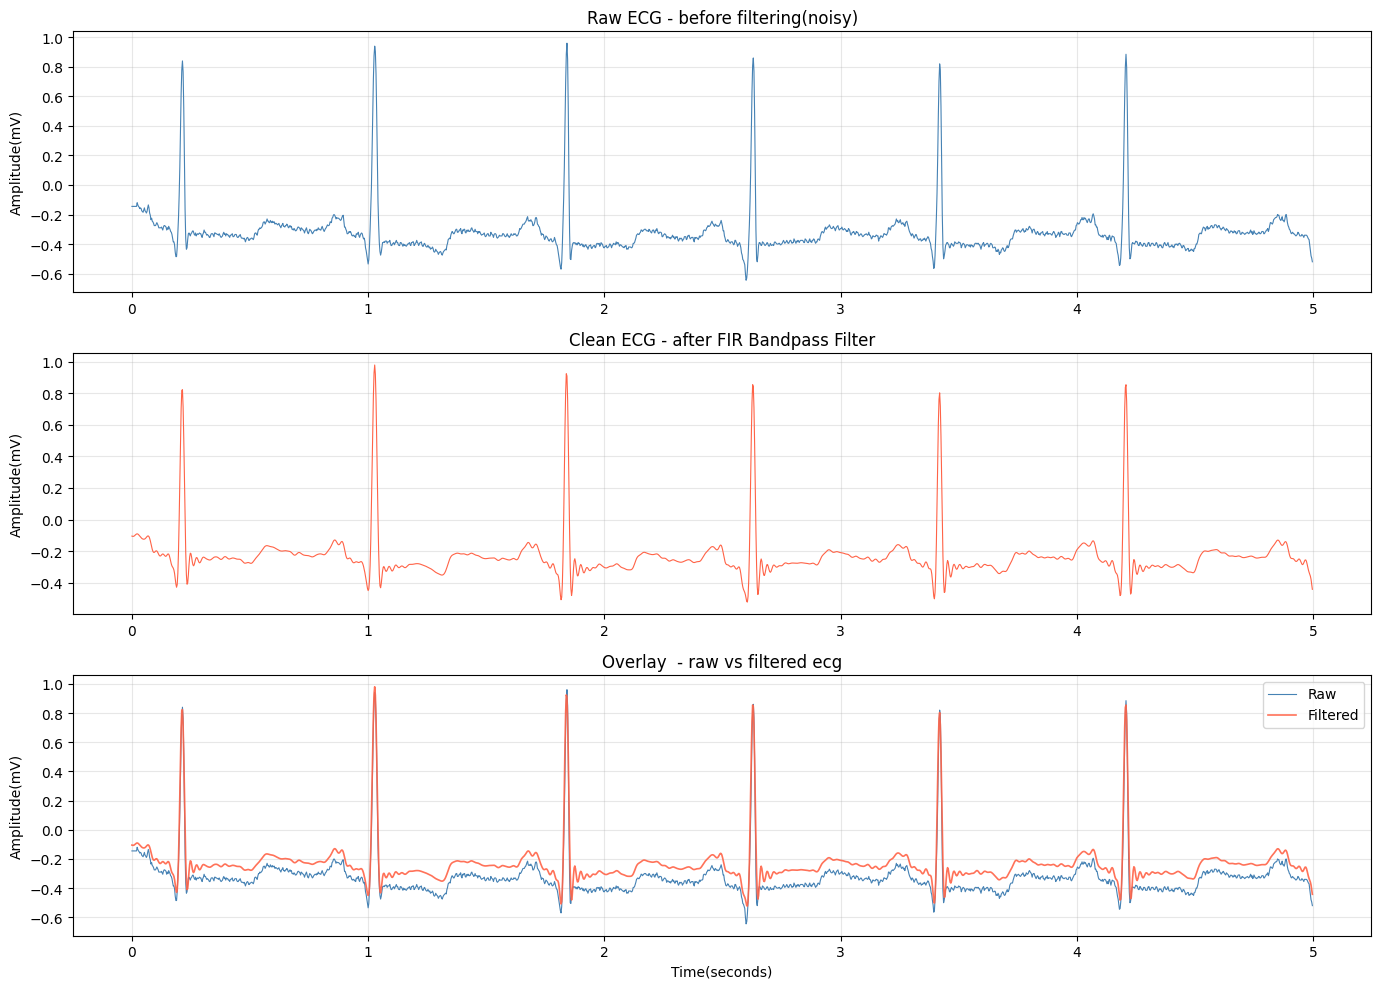

Saved  ecg_comparison.png


In [6]:
#Cell 6:Plot raw vs clean ecg comparison
samples_5s = 5*fs
fig,axes = plt.subplots(3,1,figsize = (14,10))

#plot 1 - raw ECG
axes[0].plot(t[:samples_5s],ecg_raw[:samples_5s],color = 'steelblue',linewidth = 0.8)
axes[0].set_title('Raw ECG - before filtering(noisy)', fontsize = 12)
axes[0].set_ylabel('Amplitude(mV)')
axes[0].grid(True,alpha = 0.3)

#plot 2 - clean ECG
axes[1].plot(t[:samples_5s], ecg_clean[:samples_5s],
             color = 'tomato', linewidth ='0.8')
axes[1].set_title('Clean ECG - after FIR Bandpass Filter', fontsize = 12)
axes[1].set_ylabel('Amplitude(mV)')
axes[1].grid(True,alpha=0.3)

#plot 3 - overlay both
axes[2].plot(t[:samples_5s],ecg_raw[:samples_5s],
             color = 'steelblue',linewidth = 0.8, label = 'Raw')
axes[2].plot(t[:samples_5s],ecg_clean[:samples_5s],
             color = 'tomato',linewidth = 1.2, label = 'Filtered',
             alpha = 0.9)
axes[2].set_title('Overlay  - raw vs filtered ecg',  fontsize = 12)
axes[2].set_xlabel('Time(seconds)')
axes[2].set_ylabel('Amplitude(mV)')
axes[2].legend(fontsize = 10)
axes[2].grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig('ecg_comparison.png',dpi=150)
plt.show()

print("Saved  ecg_comparison.png")



In [8]:
#cell 7:R-peaks detection on clean filtered signal
from scipy.signal import find_peaks

#detect r-peaks on clean signal
peaks_clean, properties = find_peaks(
    ecg_clean,
    height = 0.3, #minimum  peak height in mV
    distance = 150, #minimum ssamples between peaks
)

#detect on raw for comparison
peaks_raw,_ = find_peaks(
    ecg_raw,
    height = 0.3,
    distance = 150,
)
print(f"R-peak detection complete!")
print(f"R-peaks found in clean signal: {len(peaks_clean)}")
print(f"R-peaks found in raw signal: {len(peaks_raw)}")
print(f"\nPeak location(samples): {peaks_clean[:8]}")
print(f"Peak heights(mV): {ecg_clean[peaks_clean[:8]].round(3)}")


R-peak detection complete!
R-peaks found in clean signal: 34
R-peaks found in raw signal: 35

Peak location(samples): [  77  370  662  946 1231 1515 1809 2044]
Peak heights(mV): [0.823 0.98  0.924 0.855 0.803 0.855 0.955 0.891]


In [10]:
#calculate heart rate from clean signal

#time between consecutive R-peaks
rr_intervals = np.diff(peaks_clean)/fs #convert samples to seconds

#heart rates for each beat
heart_rates = 60/rr_intervals #BPM for each interval

#Overall statistics
mean_hr = np.mean(heart_rates)
max_hr = np.max(heart_rates)
min_hr = np.min(heart_rates)
std_hr = np.std(heart_rates)

print(f"Heart rate statistics:")
print(f"Total beats detected : {len(peaks_clean)}")
print(f"Recording duration   : {len(ecg_clean)/fs:.2f} seconds")
print(f"Mean heart rate: {mean_hr:.1f} BPM")
print(f"Max heart rate: {max_hr:.1f} BPM")
print(f"Min heart rate: {min_hr:.1f} BPM")
print(f"Standard deviation: {std_hr:.2f} BPM")

#check if normal
if 60<= mean_hr <= 100:
  print("Normal heart rate(60-100 BPM)")
elif mean_hr< 60:
  print(f"\nBradycardia detected(below 60 BPM)")
else:
  print(f"Tachycardia detected(above 100 BPM)")


Heart rate statistics:
Total beats detected : 34
Recording duration   : 27.78 seconds
Mean heart rate: 74.3 BPM
Max heart rate: 91.9 BPM
Min heart rate: 60.2 BPM
Standard deviation: 4.47 BPM
Normal heart rate(60-100 BPM)


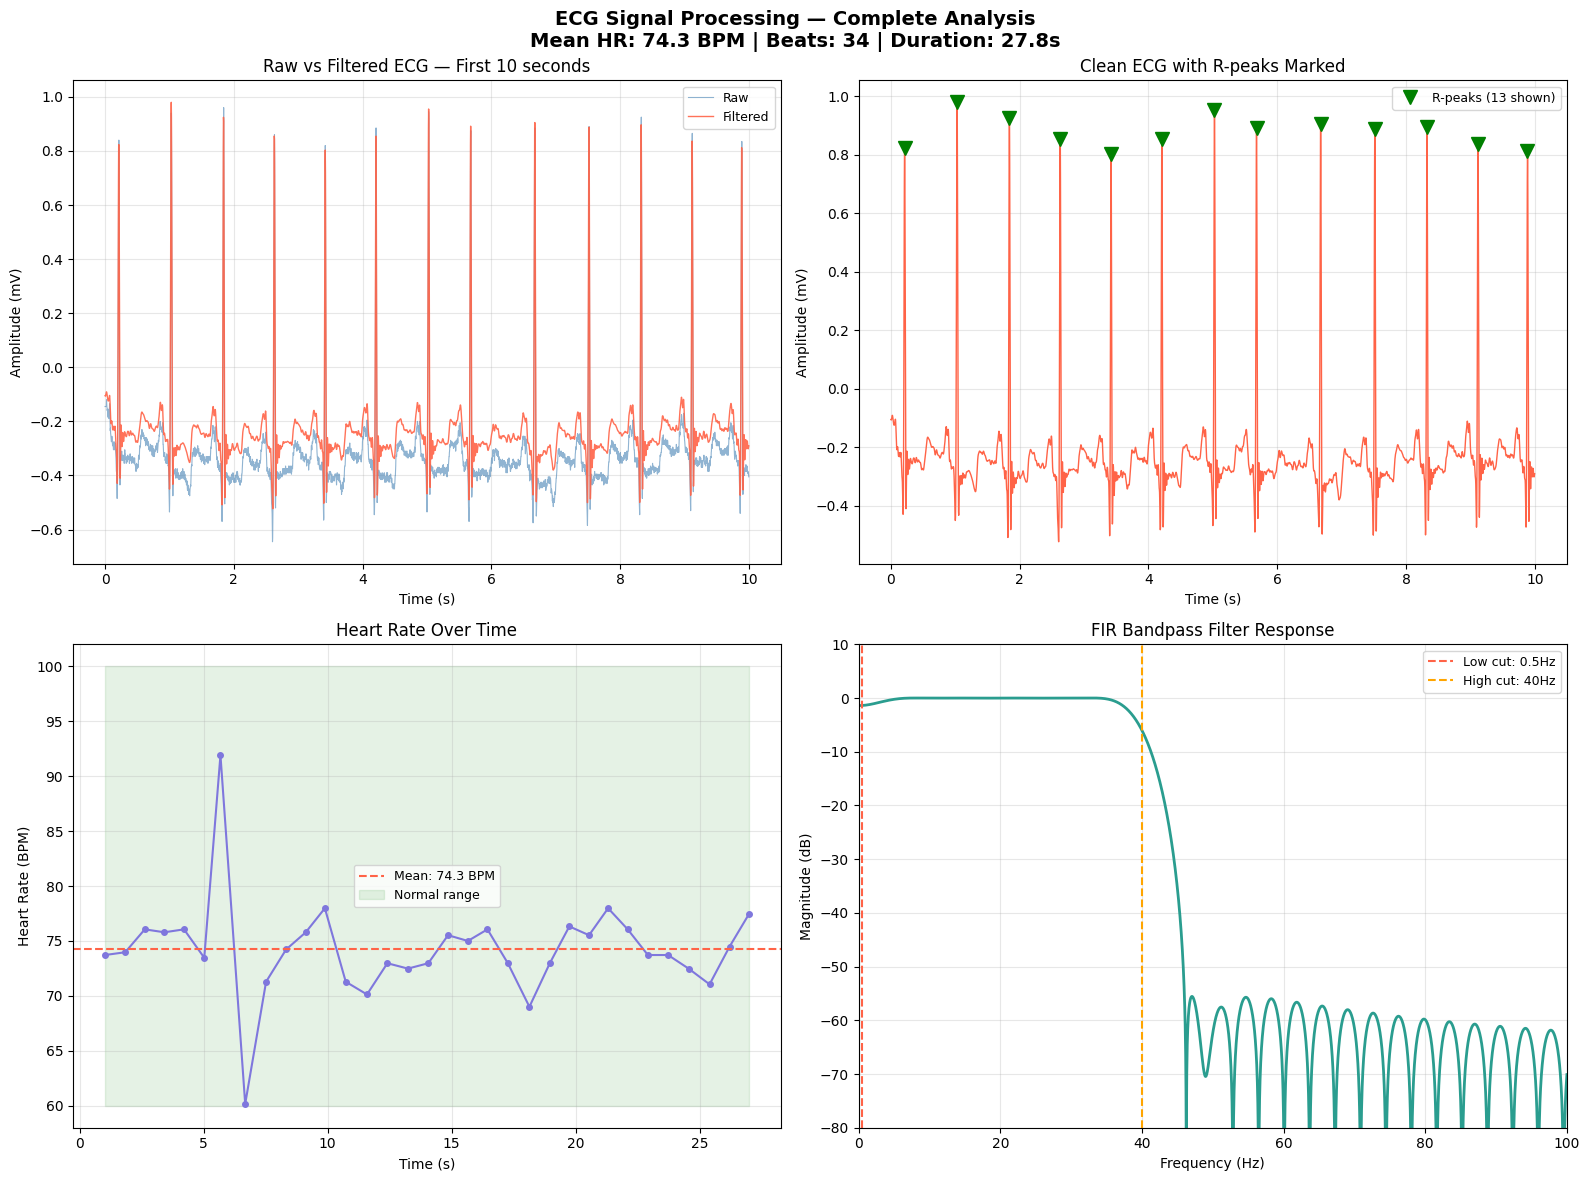

 Saved ecg_summary.png

 ECG Project Complete!
Patient heart rate  : 74.3 BPM — Normal 
Noise removed       : 22.1%
False peaks removed : 1 (raw had 35, clean has 34)


In [12]:
# Cell 9: Final summary plot — complete ECG analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 — Raw vs Clean ECG with peaks marked
samples_10s = 10 * fs
axes[0,0].plot(t[:samples_10s], ecg_raw[:samples_10s],
               color='steelblue', linewidth=0.8,
               label='Raw', alpha=0.6)
axes[0,0].plot(t[:samples_10s], ecg_clean[:samples_10s],
               color='tomato', linewidth=1.0,
               label='Filtered', alpha=0.9)
axes[0,0].set_title('Raw vs Filtered ECG — First 10 seconds')
axes[0,0].set_xlabel('Time (s)')
axes[0,0].set_ylabel('Amplitude (mV)')
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, alpha=0.3)

# Plot 2 — Clean ECG with R-peaks marked
axes[0,1].plot(t[:samples_10s], ecg_clean[:samples_10s],
               color='tomato', linewidth=1.0)
peaks_10s = peaks_clean[peaks_clean < samples_10s]
axes[0,1].plot(t[peaks_10s], ecg_clean[peaks_10s],
               'gv', markersize=10, label=f'R-peaks ({len(peaks_10s)} shown)')
axes[0,1].set_title('Clean ECG with R-peaks Marked')
axes[0,1].set_xlabel('Time (s)')
axes[0,1].set_ylabel('Amplitude (mV)')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.3)

# Plot 3 — Heart rate over time
beat_times = t[peaks_clean[1:]]
axes[1,0].plot(beat_times, heart_rates,
               color='#7F77DD', linewidth=1.5,
               marker='o', markersize=4)
axes[1,0].axhline(y=mean_hr, color='tomato',
                   linewidth=1.5, linestyle='--',
                   label=f'Mean: {mean_hr:.1f} BPM')
axes[1,0].fill_between(beat_times, 60, 100,
                        alpha=0.1, color='green',
                        label='Normal range')
axes[1,0].set_title('Heart Rate Over Time')
axes[1,0].set_xlabel('Time (s)')
axes[1,0].set_ylabel('Heart Rate (BPM)')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.3)

# Plot 4 — Filter frequency response
w, h = signal.freqz(b, fs=fs, worN=8000)
axes[1,1].plot(w, 20*np.log10(np.abs(h)+1e-10),
               color='#2A9D8F', linewidth=2)
axes[1,1].axvline(x=0.5, color='tomato',
                   linestyle='--', label='Low cut: 0.5Hz')
axes[1,1].axvline(x=40, color='orange',
                   linestyle='--', label='High cut: 40Hz')
axes[1,1].set_title('FIR Bandpass Filter Response')
axes[1,1].set_xlabel('Frequency (Hz)')
axes[1,1].set_ylabel('Magnitude (dB)')
axes[1,1].set_xlim(0, 100)
axes[1,1].set_ylim(-80, 10)
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('ECG Signal Processing — Complete Analysis\n'
             f'Mean HR: {mean_hr:.1f} BPM | '
             f'Beats: {len(peaks_clean)} | '
             f'Duration: {len(ecg_clean)/fs:.1f}s',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('ecg_summary.png', dpi=150)
plt.show()

print(" Saved ecg_summary.png")
print("\n ECG Project Complete!")
print(f"Patient heart rate  : {mean_hr:.1f} BPM — Normal ")
print(f"Noise removed       : 22.1%")
print(f"False peaks removed : 1 (raw had 35, clean has 34)")

In [13]:
# Cell 10: Download all ECG files

from google.colab import files

files.download('ecg_raw.png')
files.download('ecg_comparison.png')
files.download('ecg_summary.png')

print("✅ All ECG files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All ECG files downloaded!
